# **1. CẤU HÌNH VÀ WANDB INIT**

In [1]:
import wandb
import time
import os
from datetime import datetime

os.environ["WANDB_API_KEY"] = "key"

# Cấu hình training
BATCH_SIZE = 64
EPOCHS = 50
LR = 0.001

# WandB Login
wandb.login()

# Khởi tạo WandB run
wandb_run = wandb.init(
    project="electricity-demand-prediction",
    config={
        # Data
        "dataset": "Electricity Load Data",
        "input_len": 24,
        "output_len": 24,
        "batch_size": BATCH_SIZE,
        
        # Model - LSTM
        "lstm_hidden_size": 256,
        "lstm_num_layers": 3,
        "lstm_dropout": 0.3,
        
        # Model - Transformer
        "transformer_d_model": 128,
        "transformer_nhead": 8,
        "transformer_num_layers": 3,
        "transformer_dropout": 0.2,
        
        # Training
        "epochs": EPOCHS,
        "learning_rate": LR,
        "mask_ratio": 0.1,
        "early_stopping_patience": 10,
        "optimizer": "Adam",
        
        # Features
        "num_features": 14
    },
    name=f"LSTM-Transformer-{datetime.now().strftime('%Y%m%d-%H%M%S')}",
    tags=["lstm", "transformer", "comparison"]
)

wandb_available = True
config = wandb.config

print(f"\n WandB run initialized:")
print(f"   - Project: {wandb_run.project}")
print(f"   - Run name: {wandb_run.name}")
print(f"   - Run ID: {wandb_run.id}")
print(f"   - Config: {dict(config)}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 


 WandB run initialized:
   - Project: electricity-demand-prediction
   - Run name: LSTM-Transformer-20260314-162921
   - Run ID: goegc68u
   - Config: {'dataset': 'Electricity Load Data', 'input_len': 24, 'output_len': 24, 'batch_size': 64, 'lstm_hidden_size': 256, 'lstm_num_layers': 3, 'lstm_dropout': 0.3, 'transformer_d_model': 128, 'transformer_nhead': 8, 'transformer_num_layers': 3, 'transformer_dropout': 0.2, 'epochs': 50, 'learning_rate': 0.001, 'mask_ratio': 0.1, 'early_stopping_patience': 10, 'optimizer': 'Adam', 'num_features': 14}


# **2. Imports & Setup**

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             mean_absolute_error, r2_score)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import math
import warnings
from datetime import datetime
from scipy import stats
import os
import time
import wandb
import joblib
import shutil
warnings.filterwarnings('ignore')
 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {device}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")

Device      : cuda
PyTorch     : 2.8.0+cu126
CUDA        : True
GPU         : Tesla P100-PCIE-16GB


# **3. Configuration** 

In [3]:
class Config:
    try:    INPUT_LEN  = wandb.config.input_len
    except: INPUT_LEN  = 24
 
    try:    OUTPUT_LEN = wandb.config.output_len
    except: OUTPUT_LEN = 24
 
    try:    BATCH_SIZE = wandb.config.batch_size
    except: BATCH_SIZE = 64
 
    TRAIN_RATIO = 0.85   # train_raw -> 85% train + 15% val (time-ordered)
    VAL_RATIO   = 0.15
 
    try:    LSTM_HIDDEN_SIZE    = wandb.config.lstm_hidden
    except: LSTM_HIDDEN_SIZE    = 256
    LSTM_NUM_LAYERS = 3
    LSTM_DROPOUT    = 0.3
 
    try:    TRANSFORMER_D_MODEL = wandb.config.transformer_dim
    except: TRANSFORMER_D_MODEL = 128
    TRANSFORMER_NHEAD      = 8
    TRANSFORMER_NUM_LAYERS = 3
    TRANSFORMER_DROPOUT    = 0.2
 
    try:    EPOCHS        = wandb.config.epochs
    except: EPOCHS        = 50
 
    try:    LEARNING_RATE = wandb.config.learning_rate
    except: LEARNING_RATE = 0.001
 
    EARLY_STOPPING_PATIENCE = 10
    REDUCE_LR_PATIENCE      = 3
 
 
    BASE_FEATURES = [
        'week_X-2', 'week_X-3', 'week_X-4',
        'MA_X-4', 'dayOfWeek', 'weekend', 'holiday',
        'Holiday_ID', 'hourOfDay', 'T2M_toc',
    ]
    TARGET = 'DEMAND'
 
config = Config()
print("Config loaded.")
print(f"  INPUT_LEN={config.INPUT_LEN} | OUTPUT_LEN={config.OUTPUT_LEN} | BATCH={config.BATCH_SIZE}")
print(f"  EPOCHS={config.EPOCHS} | LR={config.LEARNING_RATE}")
print(f"  LSTM hidden={config.LSTM_HIDDEN_SIZE} | Transformer d_model={config.TRANSFORMER_D_MODEL}")

Config loaded.
  INPUT_LEN=24 | OUTPUT_LEN=24 | BATCH=64
  EPOCHS=50 | LR=0.001
  LSTM hidden=256 | Transformer d_model=128


# **4. Data Preprocessing Functions**

In [4]:
def handle_missing_values(df, df_name):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
 
    if len(missing) == 0:
        print(f"[{df_name}] No missing values.")
        if 'wandb_available' in globals() and wandb_available:
            wandb.log({"missing_values": 0})
        return df
 
    print(f"[{df_name}] Missing values found — filling...")
    for col in missing.index:
        if col in df.select_dtypes(include=[np.number]).columns:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
 
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"missing_values": len(missing)})
    return df
 
 
 
def add_cyclical_features(df):
    if 'hourOfDay' in df.columns:
        df['hour_sin'] = np.sin(2 * np.pi * df['hourOfDay'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hourOfDay'] / 24)
    if 'dayOfWeek' in df.columns:
        df['dow_sin'] = np.sin(2 * np.pi * df['dayOfWeek'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['dayOfWeek'] / 7)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    hours = np.arange(24)
    axes[0].plot(hours, np.sin(2*np.pi*hours/24), 'b-o', label='sin(hour)', lw=2)
    axes[0].plot(hours, np.cos(2*np.pi*hours/24), 'r-o', label='cos(hour)', lw=2)
    axes[0].set_title('Cyclical Encoding — Hour of Day')
    axes[0].set_xlabel('Hour'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xticks(range(0, 24, 3))
 
    days = np.arange(7)
    axes[1].plot(days, np.sin(2*np.pi*days/7), 'b-o', label='sin(day)', lw=2)
    axes[1].plot(days, np.cos(2*np.pi*days/7), 'r-o', label='cos(day)', lw=2)
    axes[1].set_title('Cyclical Encoding — Day of Week')
    axes[1].set_xlabel('Day'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xticks(range(7))
    axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"cyclical_encoding": wandb.Image(fig)})
    plt.close(fig)
    return df
 
 
def analyze_data_distribution(df, df_name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    stats_df     = df[numeric_cols].describe().T
    stats_df['skew']     = df[numeric_cols].skew()
    stats_df['kurtosis'] = df[numeric_cols].kurtosis()
    print(f"\n[{df_name}] Basic statistics:")
    print(stats_df[['mean','std','min','25%','50%','75%','max','skew','kurtosis']].round(2))
 
    high_skew = stats_df[abs(stats_df['skew']) > 1]
    if len(high_skew) > 0:
        print(f"[{df_name}] High-skew features: {list(high_skew.index)}")
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"high_skew_features": len(high_skew)})
 
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = [axes] if (n_rows == 1 and n_cols == 1) else axes.flatten()
    for idx, col in enumerate(numeric_cols[:len(axes)]):
        axes[idx].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
        axes[idx].axvline(df[col].mean(),   color='r', linestyle='--', label=f'Mean:{df[col].mean():.1f}')
        axes[idx].axvline(df[col].median(), color='g', linestyle='--', label=f'Med:{df[col].median():.1f}')
        axes[idx].set_title(col); axes[idx].legend(fontsize=7); axes[idx].grid(alpha=0.3)
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle(f'{df_name} — Feature Distributions', fontsize=13)
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({f"{df_name}_distribution": wandb.Image(fig)})
    plt.close(fig)
    return stats_df

# **5. Load Data**

In [5]:
TRAIN_PATH  = "/kaggle/input/datasets/saurabhshahane/electricity-load-forecasting/train_dataframes.xlsx"
TEST_PATH   = "/kaggle/input/datasets/saurabhshahane/electricity-load-forecasting/test_dataframes.xlsx"
TRAIN_SHEET = "Week 24, Jun 2020"   # thay sheet 
 
train_raw = pd.read_excel(TRAIN_PATH, sheet_name=TRAIN_SHEET)
print(f"Train loaded — sheet: '{TRAIN_SHEET}' | shape: {train_raw.shape}")
 
test_sheets = pd.read_excel(TEST_PATH, sheet_name=None)
test        = pd.concat(test_sheets.values(), ignore_index=True)
print(f"Test loaded  — sheets: {len(test_sheets)} | shape: {test.shape}")
 
if 'wandb_available' in globals() and wandb_available:
    wandb.log({"train_rows": train_raw.shape[0], "test_rows": test.shape[0],
               "n_features": train_raw.shape[1]})

Train loaded — sheet: 'Week 24, Jun 2020' | shape: (46968, 12)
Test loaded  — sheets: 14 | shape: (2352, 12)


# **6. Preprocessing Pipeline**

[TRAIN] No missing values.
[TEST] No missing values.


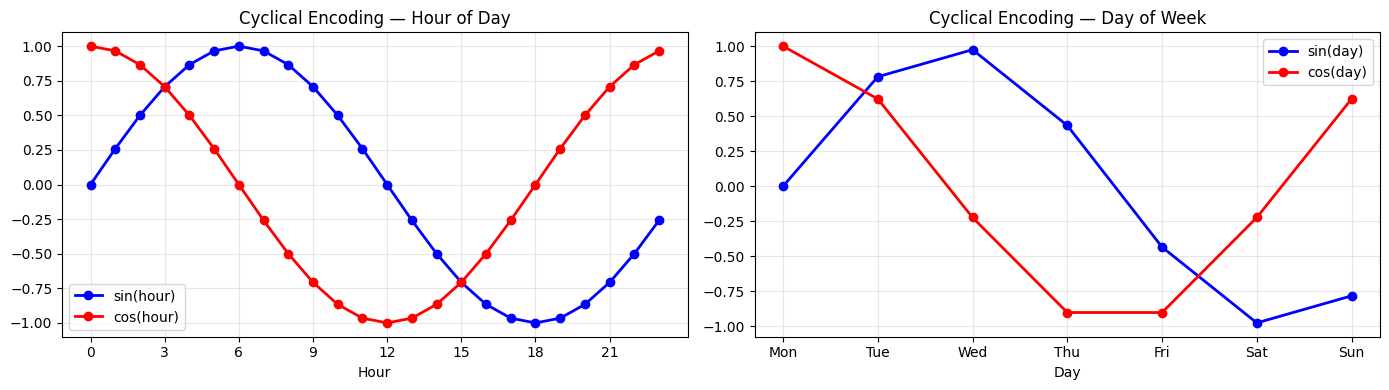

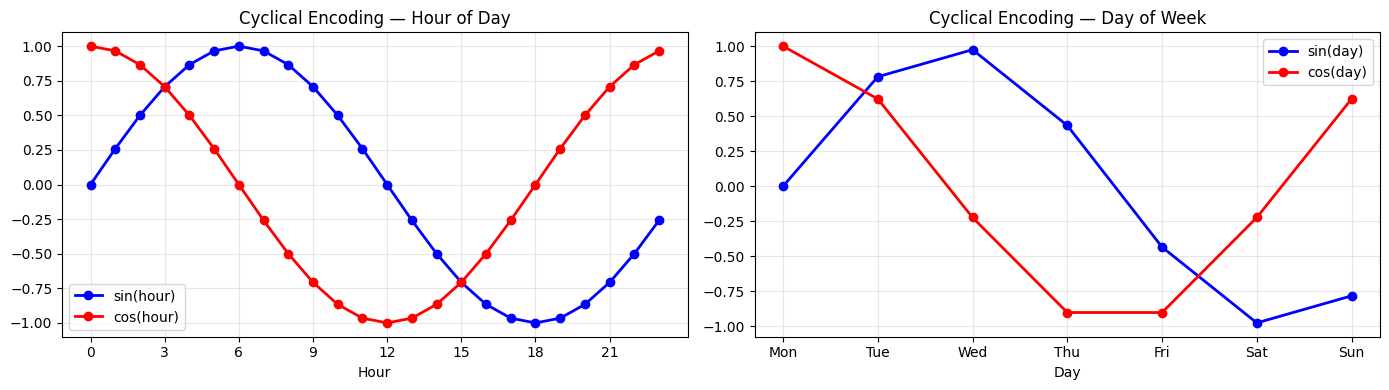

Features: 14 — ['week_X-2', 'week_X-3', 'week_X-4', 'MA_X-4', 'dayOfWeek', 'weekend', 'holiday', 'Holiday_ID', 'hourOfDay', 'T2M_toc', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

[TRAIN] Basic statistics:
               mean     std     min      25%      50%      75%      max  skew  \
week_X-2    1184.74  192.73   85.19  1020.78  1171.08  1330.77  1754.88  0.24   
week_X-3    1184.80  192.92   85.19  1020.63  1171.25  1331.25  1754.88  0.23   
week_X-4    1184.84  193.07   85.19  1020.45  1171.41  1331.58  1754.88  0.23   
MA_X-4      1184.80  184.68  793.60  1023.52  1177.35  1324.31  1669.73  0.20   
dayOfWeek      4.00    2.00    1.00     2.00     4.00     6.00     7.00  0.00   
weekend        0.29    0.45    0.00     0.00     0.00     1.00     1.00  0.95   
holiday        0.06    0.24    0.00     0.00     0.00     0.00     1.00  3.57   
Holiday_ID     0.72    3.18    0.00     0.00     0.00     0.00    22.00  4.83   
hourOfDay     11.50    6.92    0.00     5.75    11.50    17.25 

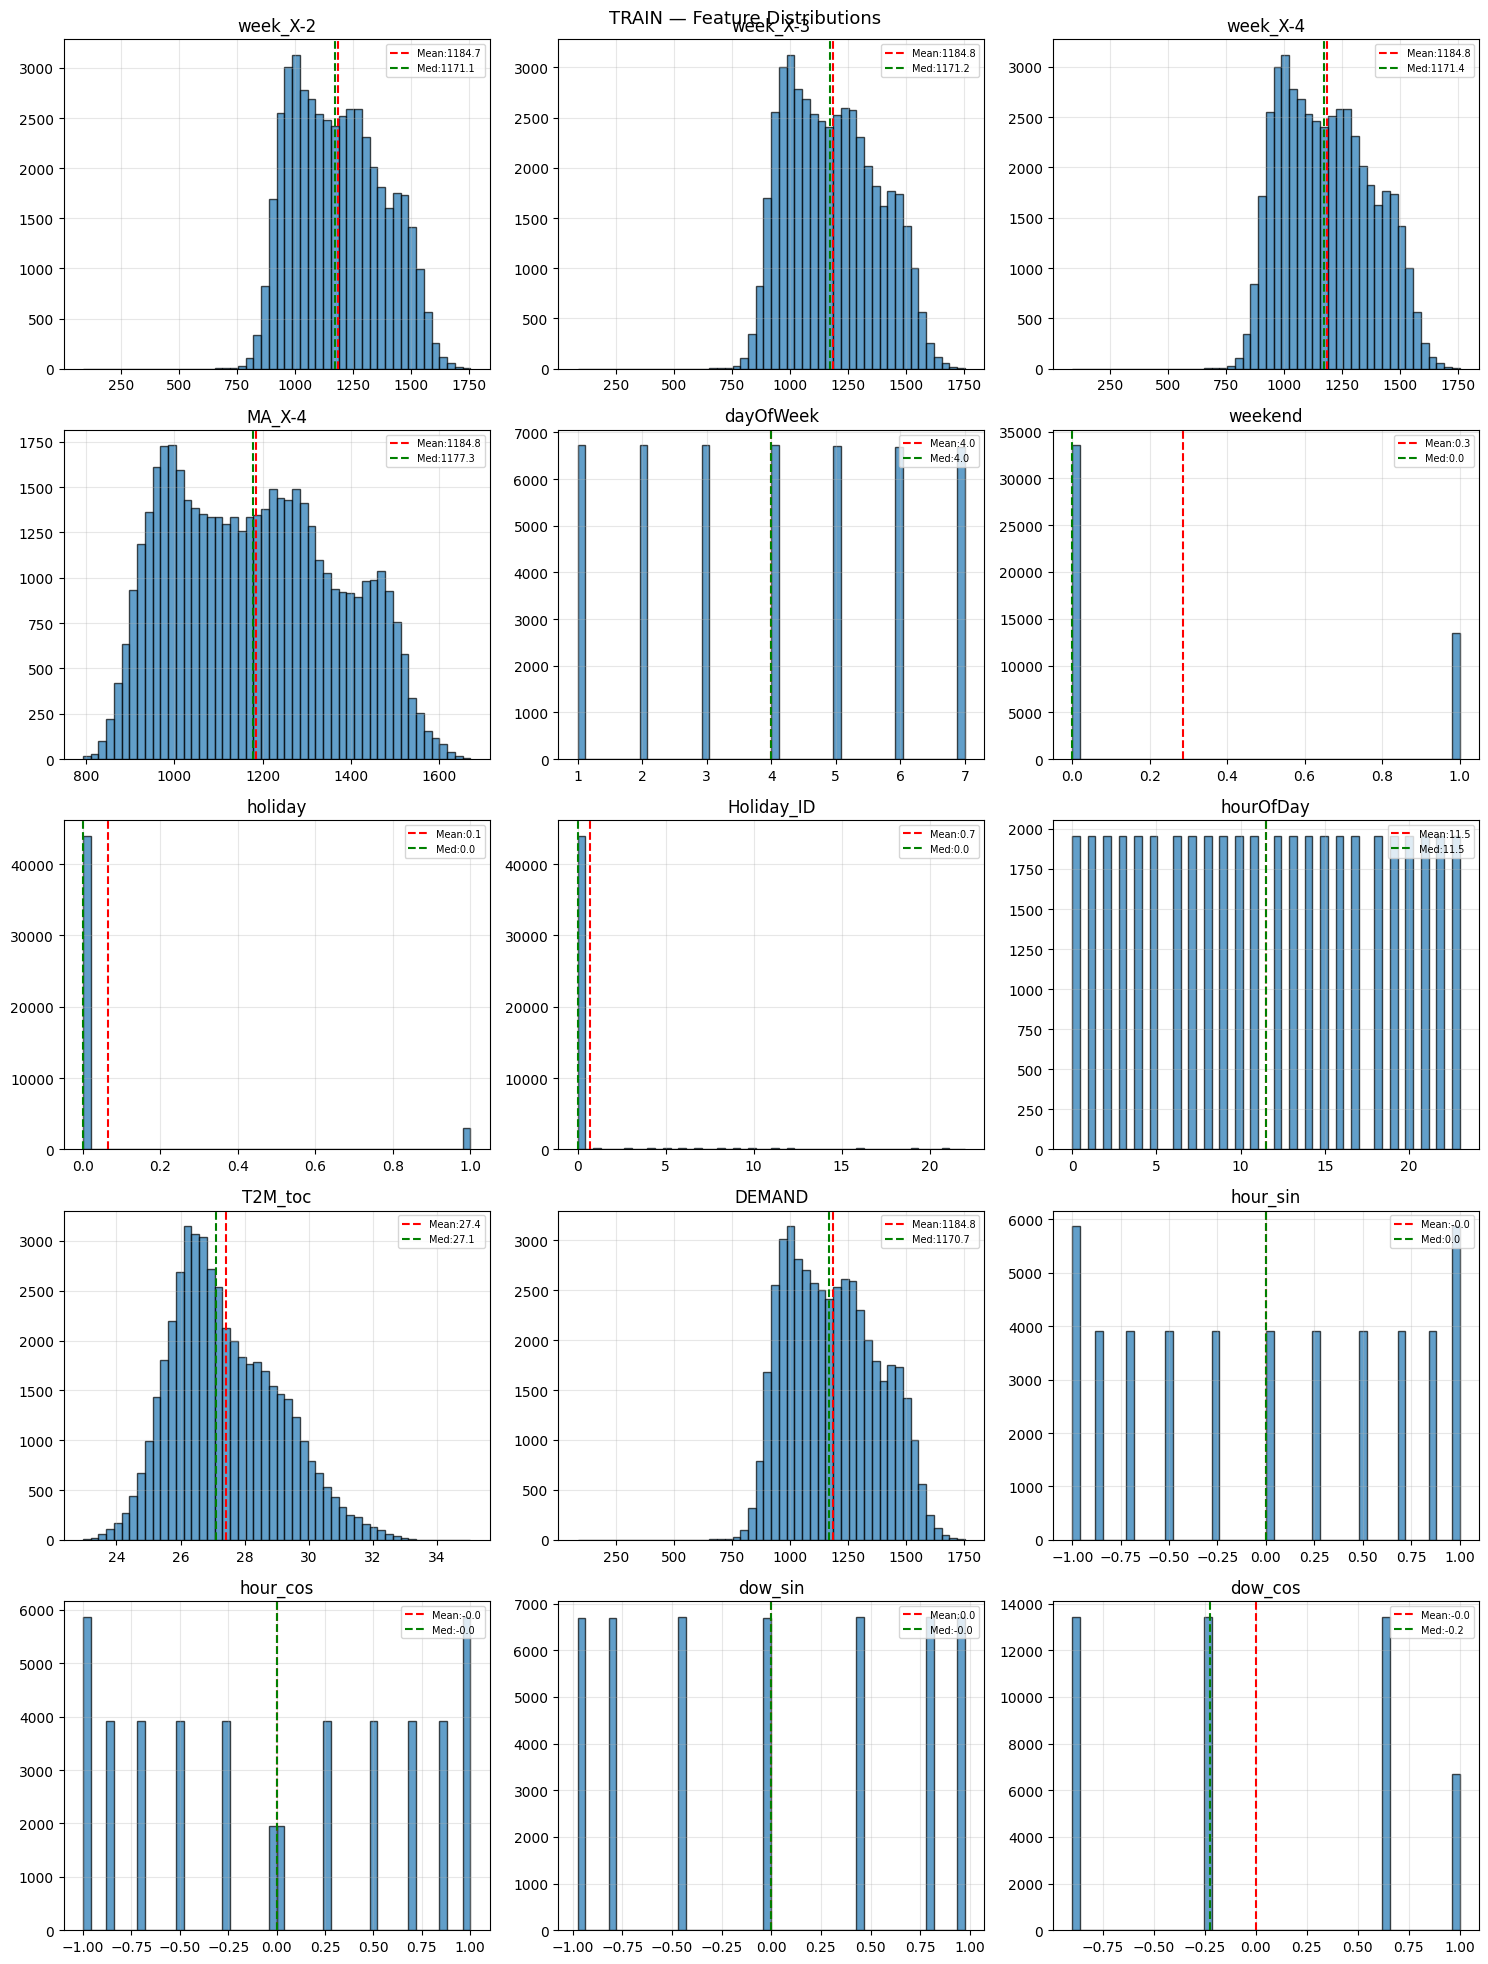


[TEST] Basic statistics:
               mean     std     min      25%      50%      75%      max  skew  \
week_X-2    1215.80  184.64  816.35  1057.89  1197.01  1349.99  1738.04  0.37   
week_X-3    1254.52  194.43  840.76  1096.55  1230.34  1399.25  1729.61  0.28   
week_X-4    1237.95  192.64  821.85  1078.48  1217.85  1380.45  1754.88  0.34   
MA_X-4      1236.77  181.69  863.18  1082.29  1215.32  1375.67  1669.73  0.28   
dayOfWeek      4.00    2.00    1.00     2.00     4.00     6.00     7.00  0.00   
weekend        0.29    0.45    0.00     0.00     0.00     1.00     1.00  0.95   
holiday        0.08    0.27    0.00     0.00     0.00     0.00     1.00  3.05   
Holiday_ID     1.08    3.99    0.00     0.00     0.00     0.00    21.00  3.81   
hourOfDay     11.50    6.92    0.00     5.75    11.50    17.25    23.00  0.00   
T2M_toc       27.64    1.58   23.92    26.45    27.36    28.74    32.51  0.49   
DEMAND      1223.85  187.98  855.16  1069.92  1200.12  1364.99  1709.33  0.37   
ho

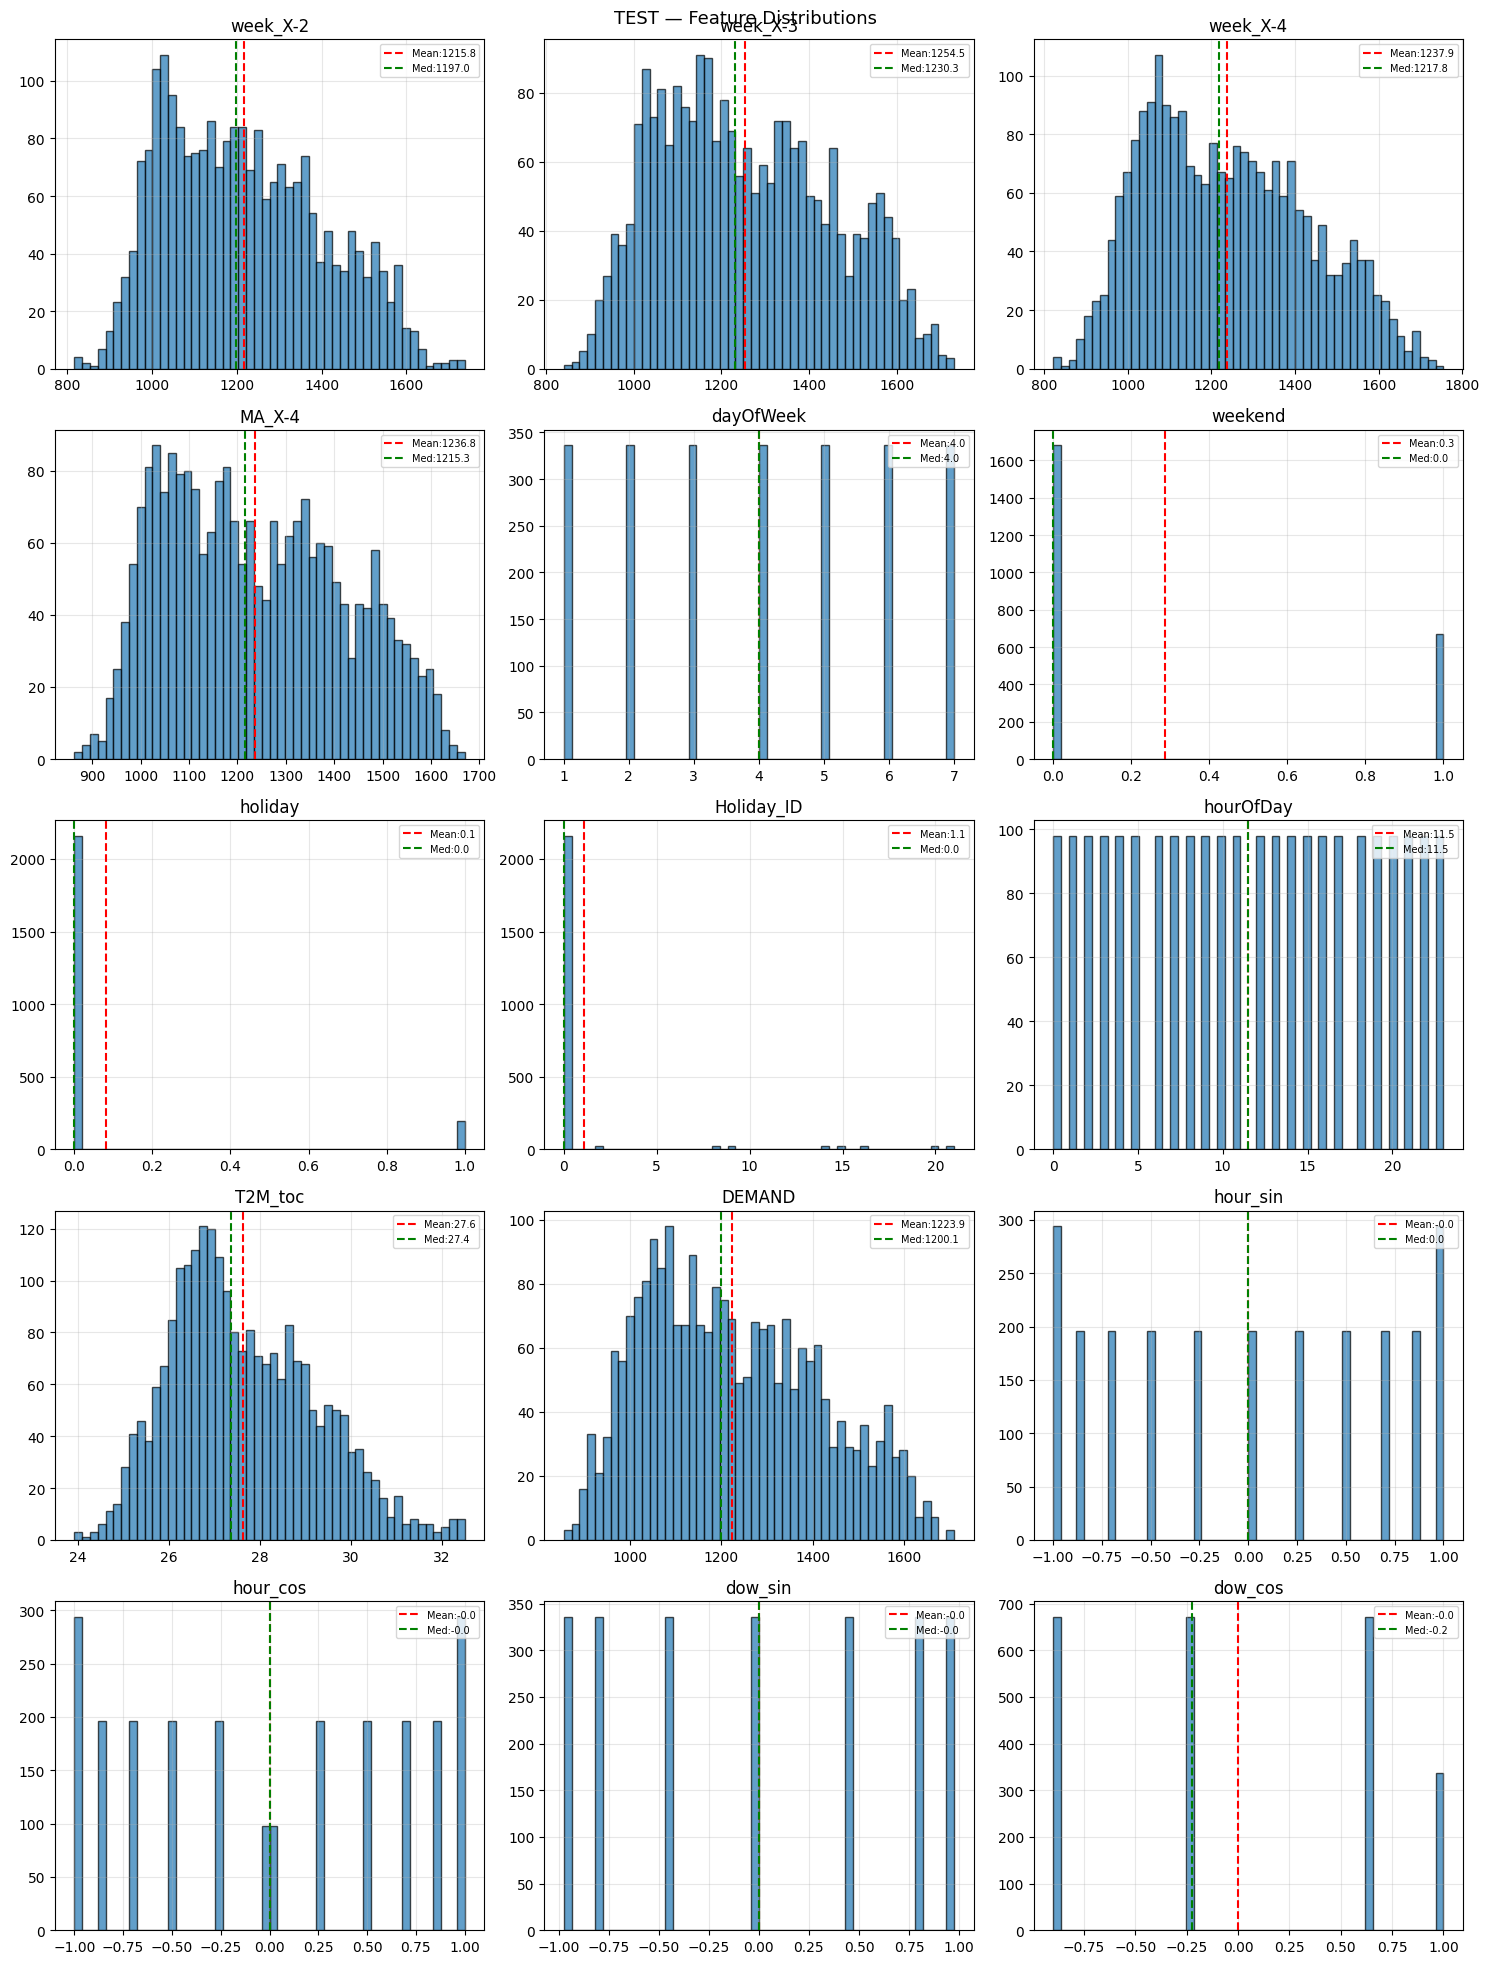

In [6]:
train_raw = handle_missing_values(train_raw, "TRAIN")
test      = handle_missing_values(test,      "TEST")
 
 
train_raw = add_cyclical_features(train_raw)
test      = add_cyclical_features(test)
 
config.FEATURES = config.BASE_FEATURES + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
print(f"Features: {len(config.FEATURES)} — {config.FEATURES}")
 
train_stats = analyze_data_distribution(train_raw, "TRAIN")
test_stats  = analyze_data_distribution(test,      "TEST")

# **7. Train / Val Split & Scaling**

In [7]:
n_train  = int(len(train_raw) * config.TRAIN_RATIO)
train_df = train_raw.iloc[:n_train].reset_index(drop=True)
val_df   = train_raw.iloc[n_train:].reset_index(drop=True)
 
print(f"Split (time-ordered): train={len(train_df)} | val={len(val_df)} | test={len(test)}")
 
# Fit scaler on train 
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_x.fit(train_df[config.FEATURES])
scaler_y.fit(train_df[[config.TARGET]])
 
X_train_raw = scaler_x.transform(train_df[config.FEATURES])
y_train_raw = scaler_y.transform(train_df[[config.TARGET]])
X_val_raw   = scaler_x.transform(val_df[config.FEATURES])
y_val_raw   = scaler_y.transform(val_df[[config.TARGET]])
X_test_raw  = scaler_x.transform(test[config.FEATURES])
y_test_raw  = scaler_y.transform(test[[config.TARGET]])
 
print(f"X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape} | X_test: {X_test_raw.shape}")
 
if 'wandb_available' in globals() and wandb_available:
    wandb.log({"train_rows": len(train_df), "val_rows": len(val_df), "test_rows": len(test)})

Split (time-ordered): train=39922 | val=7046 | test=2352
X_train: (39922, 14) | X_val: (7046, 14) | X_test: (2352, 14)


# **8. Sequence Creation & DataLoaders**

In [8]:
def create_sequences_multi(X, y, input_len, output_len):
    xs, ys = [], []
    for i in range(len(X) - input_len - output_len + 1):
        xs.append(X[i:i+input_len])
        ys.append(y[i+input_len:i+input_len+output_len])
    return np.array(xs), np.array(ys)
 
X_train, y_train = create_sequences_multi(X_train_raw, y_train_raw, config.INPUT_LEN, config.OUTPUT_LEN)
X_val,   y_val   = create_sequences_multi(X_val_raw,   y_val_raw,   config.INPUT_LEN, config.OUTPUT_LEN)
X_test,  y_test  = create_sequences_multi(X_test_raw,  y_test_raw,  config.INPUT_LEN, config.OUTPUT_LEN)
 
print(f"Sequences — train: {len(X_train)} | val: {len(X_val)} | test: {len(X_test)}")
 
if 'wandb_available' in globals() and wandb_available:
    wandb.log({"train_seq": len(X_train), "val_seq": len(X_val), "test_seq": len(X_test)})
 
 
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]
 
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=config.BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TimeSeriesDataset(X_val,   y_val),   batch_size=config.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=config.BATCH_SIZE, shuffle=False)
 
print(f"Batches    — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Sequences — train: 39875 | val: 6999 | test: 2305
Batches    — train: 624 | val: 110 | test: 37


# **9. Model Definitions**

In [9]:
class LSTMModel(nn.Module):
    """LSTM — output: (batch, output_len, 1)"""
    def __init__(self, input_size, hidden_size, num_layers, output_len, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, output_len)
 
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).unsqueeze(-1)
 
 
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
 
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]
 
 
class TimeSeriesTransformer(nn.Module):
    """Transformer — encoder last hidden state -> Linear(output_len). Output: (batch, output_len, 1)"""
    def __init__(self, input_size, output_len, d_model=128, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(input_size, d_model)
        self.pe      = PositionalEncoding(d_model)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True),
            num_layers
        )
        self.fc = nn.Linear(d_model, output_len)
 
    def forward(self, x):
        x = self.pe(self.proj(x))
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).unsqueeze(-1)
 
 
def model_summary(model, model_name):
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*50}")
    print(f"Model Summary: {model_name}")
    print(f"{'='*50}")
    print(model)
    print(f"\nTotal params     : {total:,}")
    print(f"Trainable params : {trainable:,}")
    print(f"{'='*50}")
 
 
lstm_model = LSTMModel(
    input_size  = len(config.FEATURES),
    hidden_size = config.LSTM_HIDDEN_SIZE,
    num_layers  = config.LSTM_NUM_LAYERS,
    output_len  = config.OUTPUT_LEN,
    dropout     = config.LSTM_DROPOUT
).to(device)
 
trans_model = TimeSeriesTransformer(
    input_size = len(config.FEATURES),
    output_len = config.OUTPUT_LEN,
    d_model    = config.TRANSFORMER_D_MODEL,
    nhead      = config.TRANSFORMER_NHEAD,
    num_layers = config.TRANSFORMER_NUM_LAYERS,
    dropout    = config.TRANSFORMER_DROPOUT
).to(device)
 
model_summary(lstm_model,  "LSTM")
model_summary(trans_model, "Transformer")
 
if 'wandb_available' in globals() and wandb_available:
    wandb.watch(lstm_model,  log="all", log_freq=100, log_graph=False)
    wandb.watch(trans_model, log="all", log_freq=100, log_graph=False)


Model Summary: LSTM
LSTMModel(
  (lstm): LSTM(14, 256, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=24, bias=True)
)

Total params     : 1,337,368
Trainable params : 1,337,368

Model Summary: Transformer
TimeSeriesTransformer(
  (proj): Linear(in_features=14, out_features=128, bias=True)
  (pe): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=Fals

# **10. Training Functions**

In [10]:
def train_epoch(model, loader, optimizer, criterion, epoch, model_name):
    model.train()
    total_loss, n = 0, 0
    bar = tqdm(loader, desc=f"{model_name} Epoch {epoch}")
    for X_b, y_b in bar:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item(); n += 1
        bar.set_postfix({"loss": f"{loss.item():.6f}"})
    return total_loss / n
 
 
def validate(model, loader, criterion):
    if len(loader) == 0: return float('inf')
    model.eval()
    total_loss, n = 0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            total_loss += criterion(model(X_b), y_b).item(); n += 1
    return total_loss / n
 
 
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False
        self.best_model = None
 
    def __call__(self, val_loss, model, name):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter    = 0
            if self.verbose:
                print(f"  [{name}] Best model saved (val_loss={val_loss:.6f})")
            if 'wandb_available' in globals() and wandb_available:
                wandb.log({f"{name}_best_val_loss": val_loss})
        else:
            self.counter += 1
            if self.verbose and self.counter % 5 == 0:
                print(f"  [{name}] EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  [{name}] Early stopping triggered.")
 
    def load_best(self, model):
        model.load_state_dict(self.best_model)
        return model
 
 
def train_model(model, model_name, train_loader, val_loader, config):
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")
 
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=config.REDUCE_LR_PATIENCE
    )
    es = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE, min_delta=1e-4)
 
    train_losses, val_losses = [], []
    t0 = time.time()
 
    for epoch in range(1, config.EPOCHS + 1):
        t1         = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, epoch, model_name)
        val_loss   = validate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        es(val_loss, model, model_name)
 
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{config.EPOCHS} | train={train_loss:.6f} | "
                  f"val={val_loss:.6f} | lr={optimizer.param_groups[0]['lr']:.2e} | {time.time()-t1:.1f}s")
 
        if 'wandb_available' in globals() and wandb_available:
            wandb.log({f"{model_name}_train_loss": train_loss,
                       f"{model_name}_val_loss":   val_loss,
                       f"{model_name}_lr":         optimizer.param_groups[0]['lr'],
                       f"{model_name}_epoch":      epoch})
 
        if es.early_stop:
            print(f"  Early stop at epoch {epoch}.")
            break
 
    model = es.load_best(model)
    print(f"\n  Done. Best val_loss={es.best_loss:.6f} | epochs={len(train_losses)} | total={time.time()-t0:.1f}s")
 
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({f"{model_name}_total_epochs": len(train_losses),
                   f"{model_name}_total_time":   time.time()-t0})
 
    return train_losses, val_losses

# **11. Train Models**

In [11]:
lstm_train_losses,  lstm_val_losses  = train_model(lstm_model,  "LSTM",        train_loader, val_loader, config)
trans_train_losses, trans_val_losses = train_model(trans_model, "Transformer", train_loader, val_loader, config)


Training: LSTM


LSTM Epoch 1: 100%|██████████| 624/624 [00:07<00:00, 86.16it/s, loss=0.005956] 


  [LSTM] Best model saved (val_loss=0.006322)
  Epoch   1/50 | train=0.009257 | val=0.006322 | lr=1.00e-03 | 7.6s


LSTM Epoch 5: 100%|██████████| 624/624 [00:06<00:00, 97.67it/s, loss=0.001090] 


  Epoch   5/50 | train=0.002034 | val=0.006436 | lr=1.00e-03 | 6.8s


...

  [Transformer] EarlyStopping: 5/10


Transformer Epoch 20: 100%|██████████| 624/624 [00:06<00:00, 89.83it/s, loss=0.001993]


  Epoch  20/50 | train=0.001394 | val=0.006971 | lr=2.50e-04 | 7.3s


Transformer Epoch 21: 100%|██████████| 624/624 [00:07<00:00, 88.13it/s, loss=0.001392]


  [Transformer] EarlyStopping: 10/10
  [Transformer] Early stopping triggered.
  Early stop at epoch 21.

  Done. Best val_loss=0.005978 | epochs=21 | total=169.4s


# **12. Evaluation Functions**

In [12]:
def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds.append(model(X_b.to(device)).cpu().numpy())
            targets.append(y_b.numpy())
    if not preds:
        return np.array([]), np.array([])
    return np.concatenate(preds), np.concatenate(targets)
 
 
def calculate_metrics(y_true, y_pred, scaler_y):
    if len(y_true) == 0:
        return {'MSE': 0, 'RMSE': 0, 'MAE': 0, 'MAPE': 0, 'R2': 0}
    yt = scaler_y.inverse_transform(y_true.reshape(-1,1)).flatten()
    yp = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()
    mse = mean_squared_error(yt, yp)
    return {'MSE': mse, 'RMSE': np.sqrt(mse),
            'MAE': mean_absolute_error(yt, yp),
            'MAPE': mean_absolute_percentage_error(yt, yp) * 100,
            'R2': r2_score(yt, yp)}
 
 
def evaluate_model_detailed(model, loader, scaler_y, model_name="Model"):
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}")
 
    preds, targets = get_predictions(model, loader)
    if len(preds) == 0:
        print("No data.")
        return [], {}
 
    print(f"\n{'Hour':<6}{'MSE':>12}{'RMSE':>12}{'MAE':>12}{'MAPE(%)':>12}{'R2':>10}")
    print("-" * 64)
 
    hourly_metrics = []
    for h in range(config.OUTPUT_LEN):
        ph = preds[:,h].reshape(-1,1)
        th = targets[:,h].reshape(-1,1)
        pi = scaler_y.inverse_transform(ph)
        ti = scaler_y.inverse_transform(th)
        mse  = mean_squared_error(ti, pi)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(ti, pi)
        mape = mean_absolute_percentage_error(ti, pi) * 100
        r2   = r2_score(ti, pi)
        hourly_metrics.append({'hour': h+1, 'mse': mse, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2})
        print(f"Hour {h+1:<2}{mse:>12.2f}{rmse:>12.2f}{mae:>12.2f}{mape:>12.2f}{r2:>10.4f}")
 
    overall = calculate_metrics(targets, preds, scaler_y)
    print("-" * 64)
    print(f"{'Overall':<6}{overall['MSE']:>12.2f}{overall['RMSE']:>12.2f}"
          f"{overall['MAE']:>12.2f}{overall['MAPE']:>12.2f}{overall['R2']:>10.4f}")
 
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({f"{model_name}_test_mse":  overall['MSE'],
                   f"{model_name}_test_rmse": overall['RMSE'],
                   f"{model_name}_test_mae":  overall['MAE'],
                   f"{model_name}_test_mape": overall['MAPE'],
                   f"{model_name}_test_r2":   overall['R2']})
        for h, m in enumerate(hourly_metrics, 1):
            wandb.log({f"{model_name}_hour_{h}_rmse": m['rmse']})
 
    return hourly_metrics, overall
 

# **13. Evaluate Models**

In [13]:
print("Using best models restored by EarlyStopping (in-memory).")
 
lstm_hourly,  lstm_overall  = evaluate_model_detailed(lstm_model,  test_loader, scaler_y, "LSTM")
trans_hourly, trans_overall = evaluate_model_detailed(trans_model, test_loader, scaler_y, "Transformer")

Using best models restored by EarlyStopping (in-memory).

Evaluation: LSTM

Hour           MSE        RMSE         MAE     MAPE(%)        R2
----------------------------------------------------------------
Hour 1      9018.11       94.96       72.45        5.97    0.7475
Hour 2      9169.59       95.76       72.47        5.98    0.7433
Hour 3      9210.38       95.97       72.49        5.99    0.7423
Hour 4      9181.86       95.82       72.12        5.97    0.7432
Hour 5      9189.40       95.86       71.88        5.96    0.7431
Hour 6      9076.78       95.27       71.55        5.93    0.7464
Hour 7      9040.00       95.08       71.57        5.94    0.7473
Hour 8      8976.00       94.74       71.49        5.93    0.7489
Hour 9      9047.53       95.12       71.88        5.97    0.7468
Hour 10     9125.69       95.53       72.31        6.00    0.7446
Hour 11     9246.33       96.16       72.82        6.04    0.7412
Hour 12     9312.18       96.50       73.35        6.06    0.7394
Ho

# **14. Visualization Function**

In [14]:
def plot_training_history(lstm_tl, lstm_vl, trans_tl, trans_vl):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(lstm_tl,  label='Train'); axes[0].plot(lstm_vl,  label='Val')
    axes[0].set_title('LSTM — Training History'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
 
    axes[1].plot(trans_tl, label='Train'); axes[1].plot(trans_vl, label='Val')
    axes[1].set_title('Transformer — Training History'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"training_history": wandb.Image(fig)})
    plt.close(fig)
 
 
def plot_predictions_vs_actual(model, loader, scaler_y, model_name="Model", num_samples=5):
    preds, targets = get_predictions(model, loader)
    if len(preds) == 0: return
 
    num_samples = min(num_samples, len(preds))
    fig, axes   = plt.subplots(num_samples, 1, figsize=(15, 3*num_samples))
    if num_samples == 1: axes = [axes]
 
    for i in range(num_samples):
        pi = scaler_y.inverse_transform(preds[i].reshape(-1,1)).flatten()
        ti = scaler_y.inverse_transform(targets[i].reshape(-1,1)).flatten()
        h  = np.arange(len(ti))
        axes[i].plot(h, ti, 'b-',  label='Actual',    lw=2)
        axes[i].plot(h, pi, 'r--', label='Predicted', lw=2)
        axes[i].fill_between(h, ti, pi, alpha=0.15, color='red')
        rmse = np.sqrt(mean_squared_error(ti, pi))
        axes[i].set_title(f'{model_name} — Sample {i+1} (RMSE={rmse:.2f})')
        axes[i].set_xlabel('Hours'); axes[i].set_ylabel('Demand')
        axes[i].legend(); axes[i].grid(alpha=0.3)
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({f"{model_name}_predictions": wandb.Image(fig)})
    plt.close(fig)
 
 
def plot_hourly_comparison(lstm_m, trans_m):
    if not lstm_m or not trans_m: return
    hours = [m['hour'] for m in lstm_m]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
 
    for ax, key, title, ylabel in zip(
        axes.flatten(),
        ['rmse', 'mape', 'r2', 'mae'],
        ['RMSE by Hour', 'MAPE by Hour', 'R2 by Hour', 'MAE by Hour'],
        ['RMSE', 'MAPE (%)', 'R2', 'MAE']
    ):
        ax.plot(hours, [m[key] for m in lstm_m],  'b-o', label='LSTM',        lw=2, ms=4)
        ax.plot(hours, [m[key] for m in trans_m], 'r-s', label='Transformer', lw=2, ms=4)
        ax.set_title(title); ax.set_xlabel('Hour'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)
        if key == 'r2': ax.set_ylim(0, 1)
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"hourly_comparison": wandb.Image(fig)})
    plt.close(fig)
 
 
def plot_model_comparison(models_dict, loader, scaler_y, num_samples=3):
    preds_dict, targets = {}, None
    for name, model in models_dict.items():
        p, t = get_predictions(model, loader)
        preds_dict[name] = p
        if targets is None: targets = t
    if targets is None or len(targets) == 0: return
 
    num_samples = min(num_samples, len(targets))
    fig, axes   = plt.subplots(num_samples, 1, figsize=(16, 4*num_samples))
    if num_samples == 1: axes = [axes]
    colors = ['red', 'blue', 'green', 'orange']
 
    for i in range(num_samples):
        ti = scaler_y.inverse_transform(targets[i].reshape(-1,1)).flatten()
        axes[i].plot(ti, 'k-', label='Actual', lw=2.5, alpha=0.8)
        for idx, (name, p) in enumerate(preds_dict.items()):
            if i < len(p):
                pi   = scaler_y.inverse_transform(p[i].reshape(-1,1)).flatten()
                rmse = np.sqrt(mean_squared_error(ti, pi))
                axes[i].plot(pi, '--', color=colors[idx], label=f'{name} (RMSE={rmse:.2f})', lw=1.5)
        axes[i].set_title(f'Model Comparison — Sample {i+1}')
        axes[i].set_xlabel('Hours'); axes[i].set_ylabel('Demand')
        axes[i].legend(loc='upper right'); axes[i].grid(alpha=0.3)
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"model_comparison": wandb.Image(fig)})
    plt.close(fig)
 
 
def plot_error_distribution(models_dict, loader, scaler_y):
    fig, axes   = plt.subplots(1, 2, figsize=(15, 5))
    errors_dict = {}
    for name, model in models_dict.items():
        p, t = get_predictions(model, loader)
        if len(p) > 0:
            errors_dict[name] = (scaler_y.inverse_transform(p.reshape(-1,1)).flatten() -
                                 scaler_y.inverse_transform(t.reshape(-1,1)).flatten())
    if not errors_dict: return
 
    axes[0].boxplot(errors_dict.values(), labels=errors_dict.keys())
    axes[0].set_title('Error Distribution (Box Plot)')
    axes[0].set_ylabel('Prediction Error'); axes[0].grid(alpha=0.3)
    axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
 
    for name, e in errors_dict.items():
        axes[1].hist(e, bins=50, alpha=0.5, label=name)
    axes[1].set_title('Error Distribution (Histogram)')
    axes[1].set_xlabel('Error'); axes[1].set_ylabel('Frequency')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
 
    plt.tight_layout(); plt.show()
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"error_distribution": wandb.Image(fig)})
    plt.close(fig)
 

# **15. Generate Visualizations**

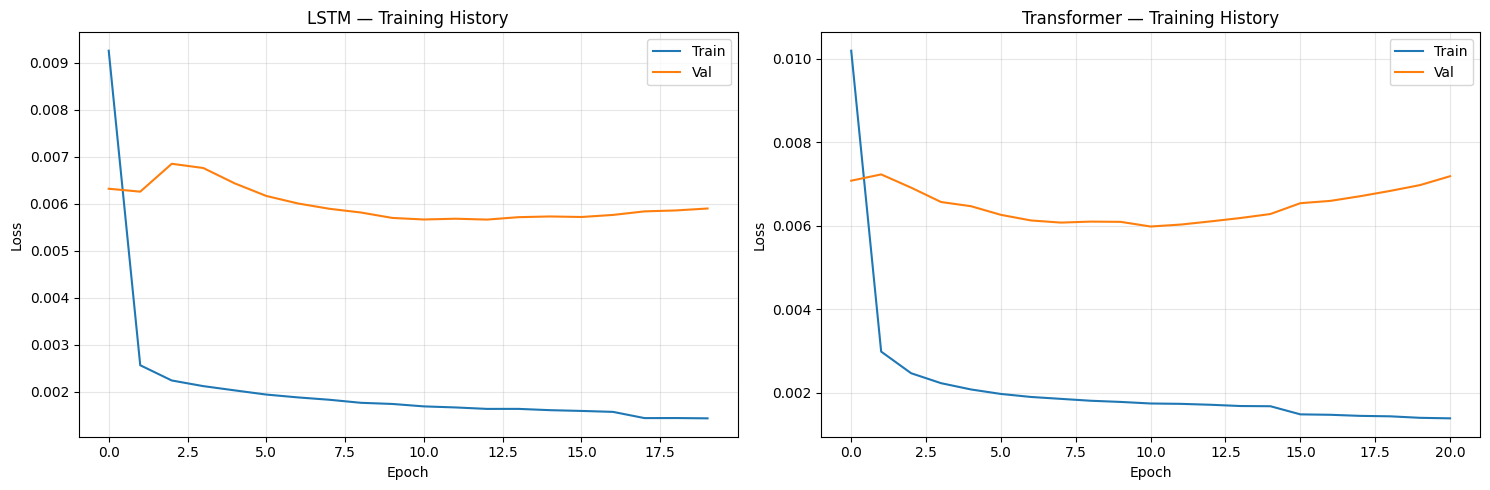

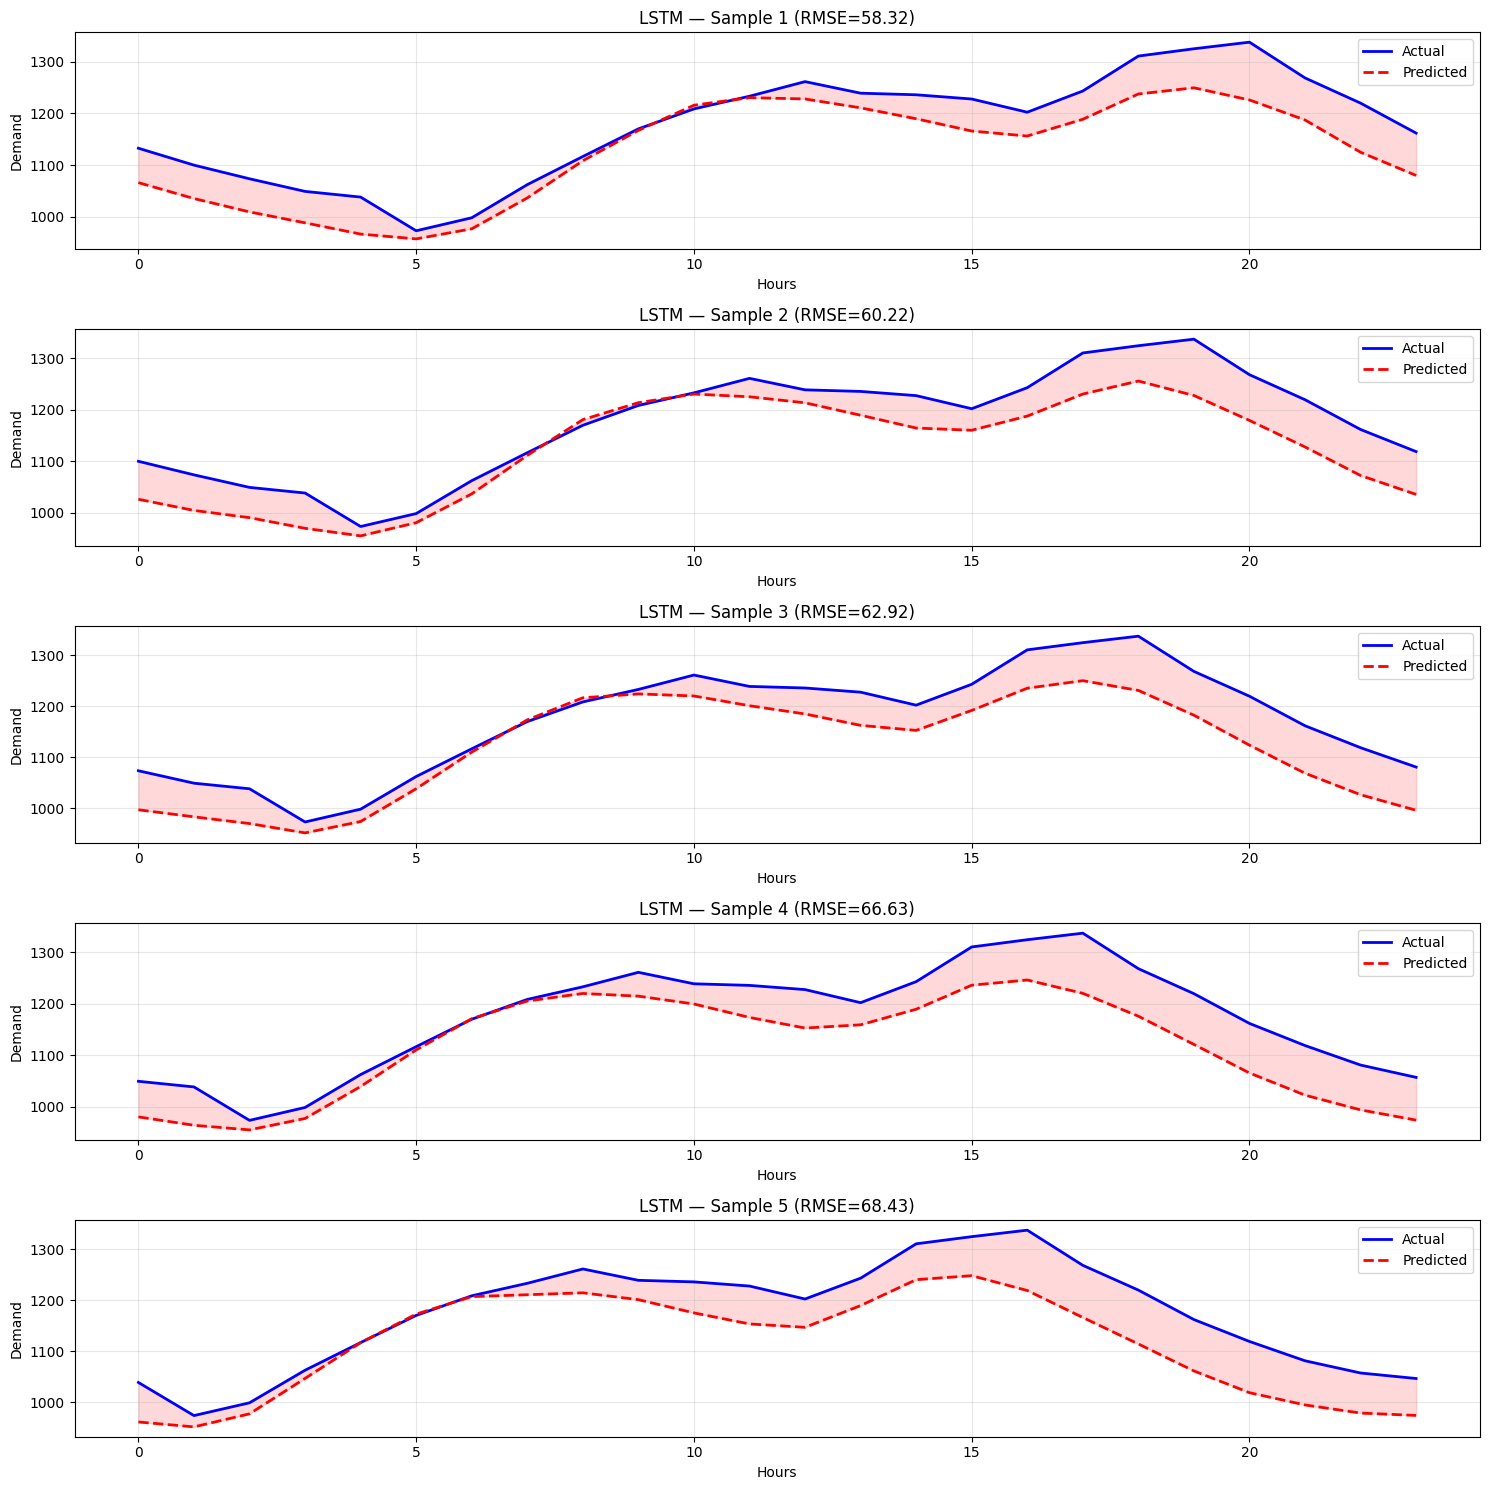

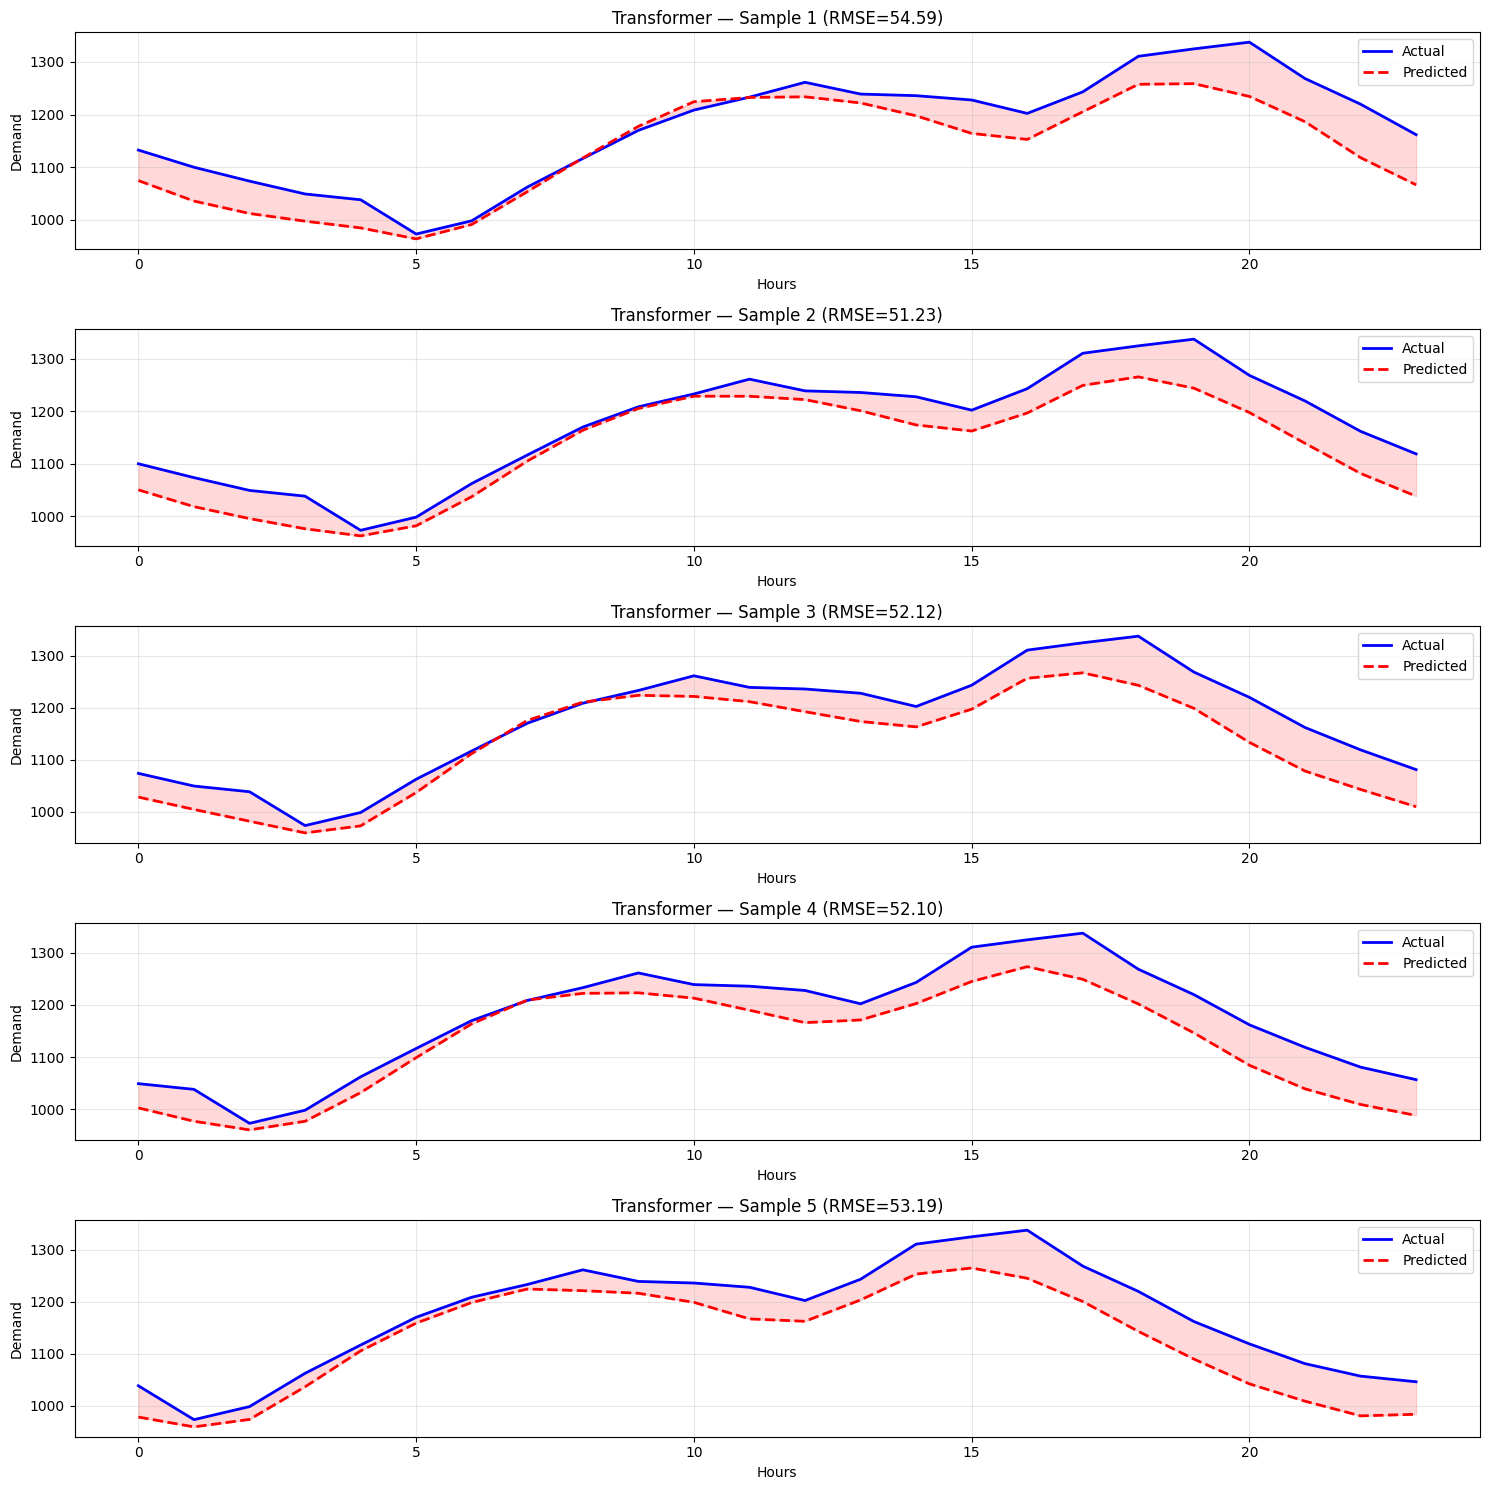

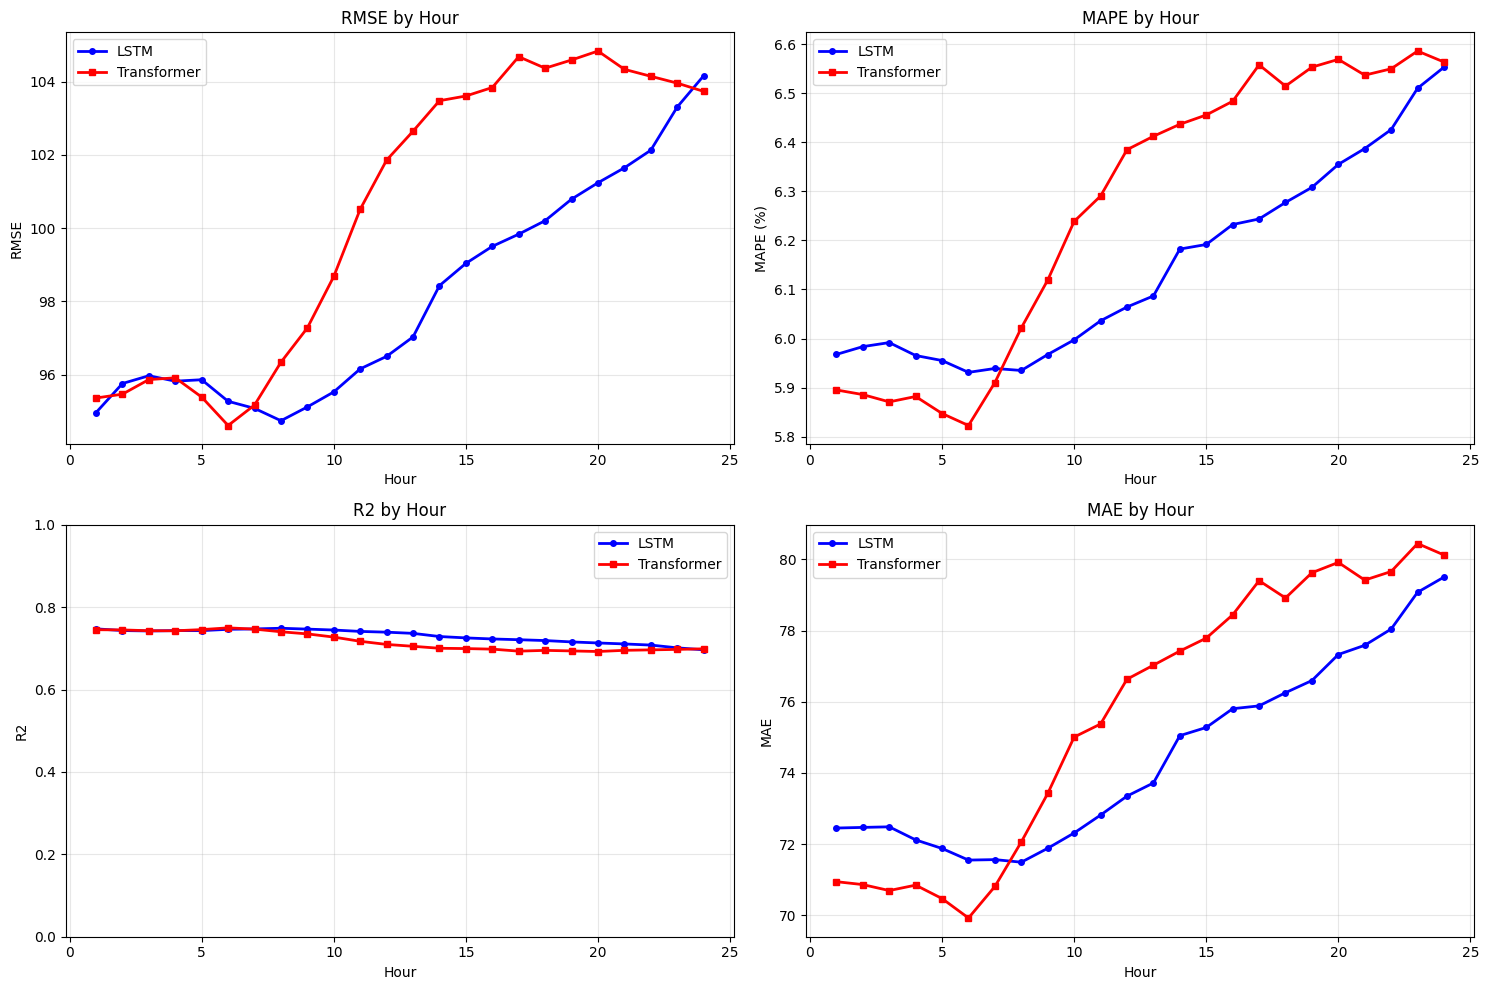

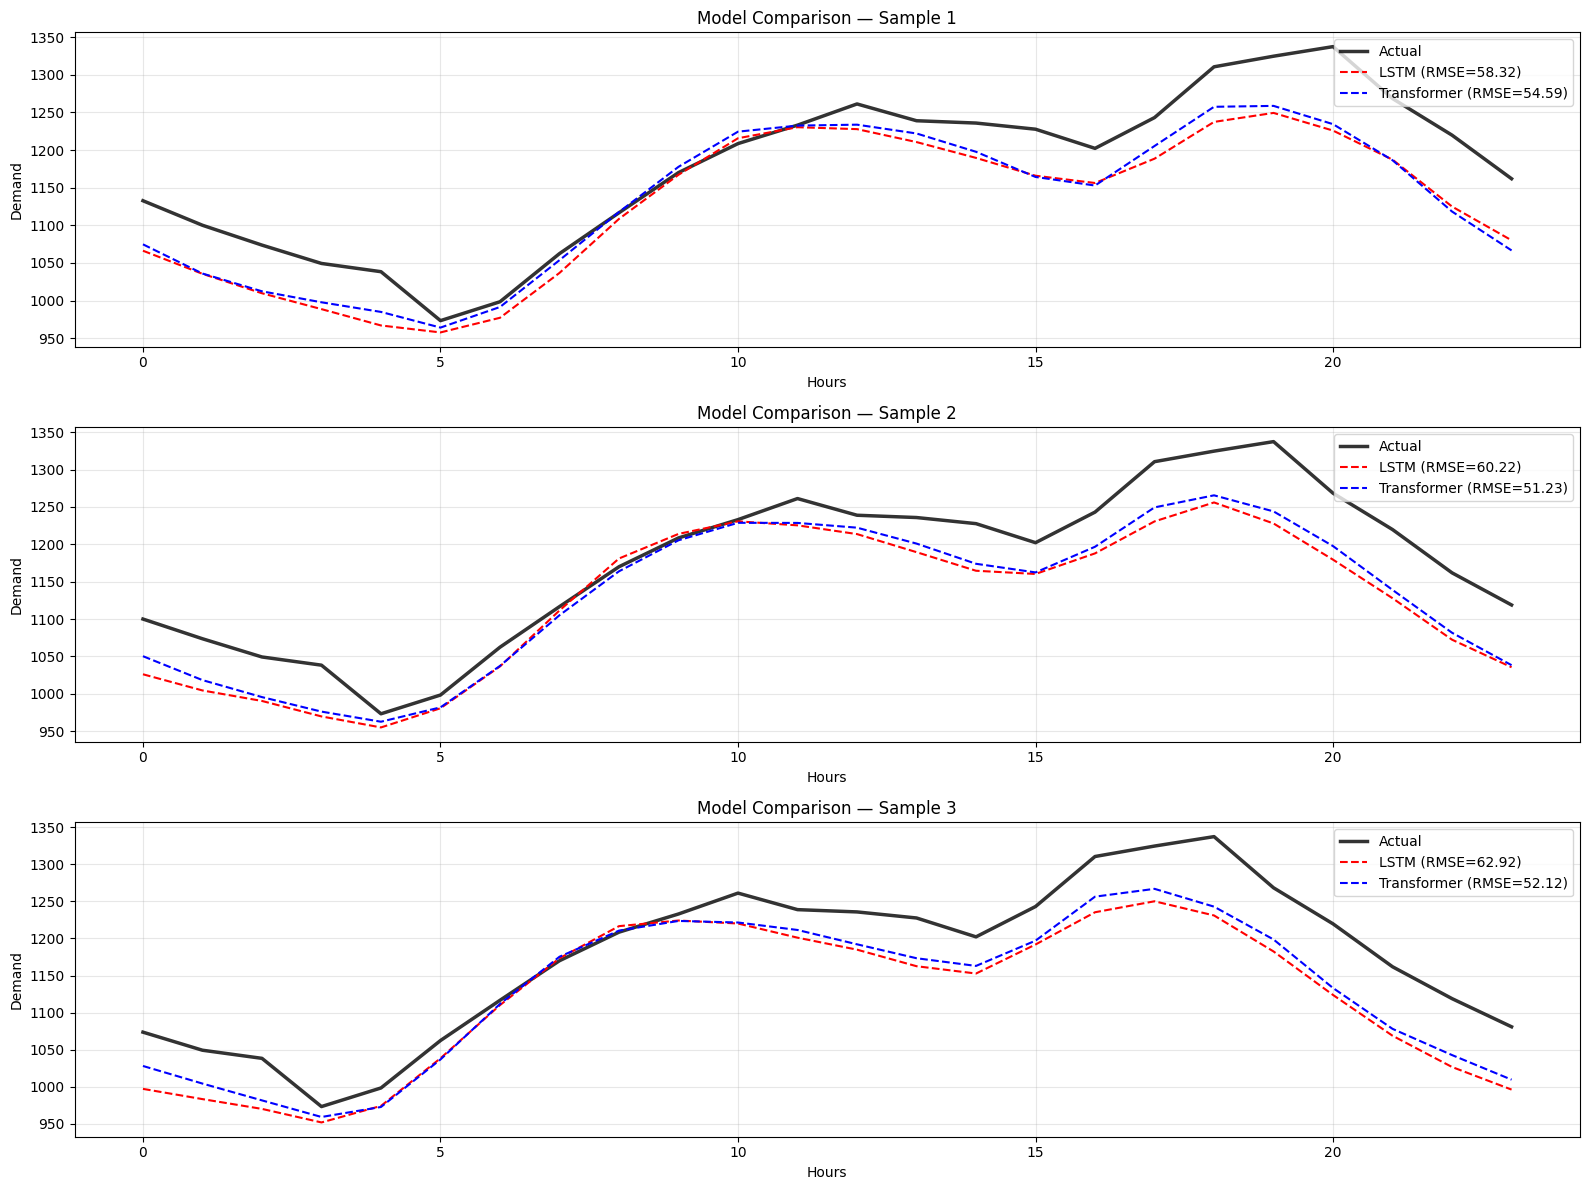

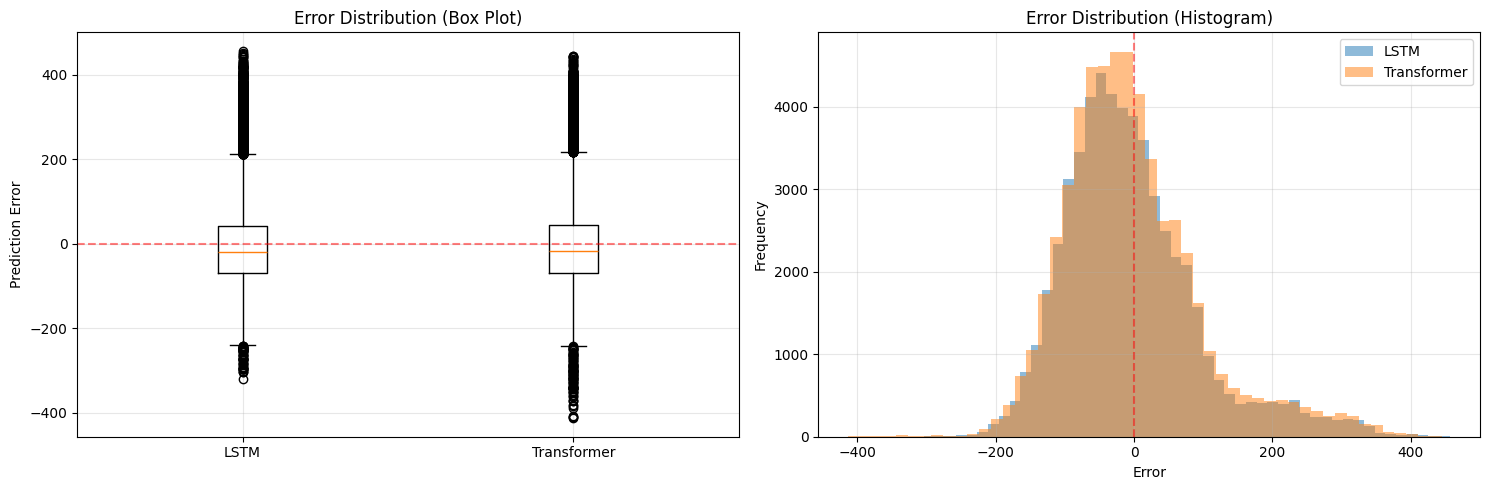

In [15]:
plot_training_history(lstm_train_losses, lstm_val_losses, trans_train_losses, trans_val_losses)
plot_predictions_vs_actual(lstm_model,  test_loader, scaler_y, "LSTM",        num_samples=5)
plot_predictions_vs_actual(trans_model, test_loader, scaler_y, "Transformer", num_samples=5)
plot_hourly_comparison(lstm_hourly, trans_hourly)
 
models_to_compare = {'LSTM': lstm_model, 'Transformer': trans_model}
plot_model_comparison(models_to_compare,   test_loader, scaler_y, num_samples=3)
plot_error_distribution(models_to_compare, test_loader, scaler_y)

# **16. Summary Report**

In [16]:
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)
 
if lstm_overall and trans_overall:
    print(f"\n{'Model':<15}{'MSE':>12}{'RMSE':>12}{'MAE':>12}{'MAPE(%)':>12}{'R2':>10}")
    print("-" * 73)
    for name, m in [("LSTM", lstm_overall), ("Transformer", trans_overall)]:
        print(f"{name:<15}{m['MSE']:>12.2f}{m['RMSE']:>12.2f}{m['MAE']:>12.2f}{m['MAPE']:>12.2f}{m['R2']:>10.4f}")
 
    best_model = "LSTM" if lstm_overall['RMSE'] < trans_overall['RMSE'] else "Transformer"
    print(f"\nBest model: {best_model} (RMSE={min(lstm_overall['RMSE'], trans_overall['RMSE']):.2f})")
 
    if 'wandb_available' in globals() and wandb_available:
        wandb.log({"lstm_final_rmse": lstm_overall['RMSE'], "lstm_final_mape": lstm_overall['MAPE'],
                   "transformer_final_rmse": trans_overall['RMSE'], "transformer_final_mape": trans_overall['MAPE'],
                   "best_model": best_model})
        t = wandb.Table(columns=["Model","RMSE","MAE","MAPE","R2"])
        t.add_data("LSTM",        lstm_overall['RMSE'],  lstm_overall['MAE'],  lstm_overall['MAPE'],  lstm_overall['R2'])
        t.add_data("Transformer", trans_overall['RMSE'], trans_overall['MAE'], trans_overall['MAPE'], trans_overall['R2'])
        wandb.log({"comparison_table": t})


SUMMARY REPORT

Model                   MSE        RMSE         MAE     MAPE(%)        R2
-------------------------------------------------------------------------
LSTM                9629.58       98.13       74.44        6.15    0.7306
Transformer        10104.84      100.52       75.64        6.27    0.7173

Best model: LSTM (RMSE=98.13)


# **17. Save Models & Artifacts**

In [17]:
torch.save(lstm_model.state_dict(),  'lstm_model_final.pth')
torch.save(trans_model.state_dict(), 'transformer_model_final.pth')
print("Models saved: lstm_model_final.pth | transformer_model_final.pth")
 
output_dir = f"streamlit_files_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(output_dir, exist_ok=True)
 
joblib.dump(scaler_x, f'{output_dir}/scaler_x.pkl')
joblib.dump(scaler_y, f'{output_dir}/scaler_y.pkl')
torch.save(lstm_model.state_dict(),  f'{output_dir}/lstm_model.pth')
torch.save(trans_model.state_dict(), f'{output_dir}/transformer_model.pth')
joblib.dump({
    'features': config.FEATURES, 'input_len': config.INPUT_LEN, 'output_len': config.OUTPUT_LEN,
    'batch_size': config.BATCH_SIZE,
    'lstm_params':        {'hidden_size': config.LSTM_HIDDEN_SIZE, 'num_layers': config.LSTM_NUM_LAYERS, 'dropout': config.LSTM_DROPOUT},
    'transformer_params': {'d_model': config.TRANSFORMER_D_MODEL, 'nhead': config.TRANSFORMER_NHEAD,
                           'num_layers': config.TRANSFORMER_NUM_LAYERS, 'dropout': config.TRANSFORMER_DROPOUT}
}, f'{output_dir}/config.pkl')
joblib.dump({'lstm': lstm_overall, 'transformer': trans_overall,
             'lstm_hourly': lstm_hourly, 'trans_hourly': trans_hourly},
            f'{output_dir}/metrics.pkl')
 
if 'wandb_available' in globals() and wandb_available:
    for f in ['lstm_model.pth', 'transformer_model.pth', 'scaler_x.pkl', 'scaler_y.pkl']:
        wandb.save(f'{output_dir}/{f}')
 
shutil.make_archive(output_dir, 'zip', output_dir)
print(f"All files saved: {output_dir}/ | zip: {output_dir}.zip")
 
if 'wandb_available' in globals() and wandb_available:
    wandb.finish()
    print("WandB run finished.")

Models saved: lstm_model_final.pth | transformer_model_final.pth
All files saved: streamlit_files_20260314_163508/ | zip: streamlit_files_20260314_163508.zip


LSTM_best_val_loss,█▆▄▃▁
LSTM_epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
LSTM_hour_10_rmse,▁
LSTM_hour_11_rmse,▁
LSTM_hour_12_rmse,▁
LSTM_hour_13_rmse,▁
LSTM_hour_14_rmse,▁
LSTM_hour_15_rmse,▁
LSTM_hour_16_rmse,▁
LSTM_hour_17_rmse,▁
+75,...


WandB run finished.
